In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\ADMIN\Downloads\Amazon Review Analysis Dataset\Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv")
df.head()
df.columns

Index(['name', 'brand', 'categories', 'reviews.rating', 'reviews.text'], dtype='object')

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            112 non-null    object
 1   brand           112 non-null    object
 2   categories      112 non-null    object
 3   reviews.rating  112 non-null    int64 
 4   reviews.text    112 non-null    object
dtypes: int64(1), object(4)
memory usage: 4.5+ KB


In [3]:
df.isnull().sum()

name              0
brand             0
categories        0
reviews.rating    0
reviews.text      0
dtype: int64

In [4]:
df = df[['name', 'brand', 'categories', 'reviews.rating', 'reviews.text']]

In [5]:
df.head()

,name,brand,categories,reviews.rating,reviews.text
0,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,"Computers,Electronics Features,Tablets,Electro...",1,I was looking for a kindle whitepaper. I saw o...
1,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,"Computers,Electronics Features,Tablets,Electro...",1,Looking at the picture and seeing it was 8th g...
2,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,"Computers,Electronics Features,Tablets,Electro...",2,it would not load my books proper. took a doze...
3,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,"Computers,Electronics Features,Tablets,Electro...",2,"The screen is too dark, and cannot adjust the ..."
4,Amazon Echo Show Alexa-enabled Bluetooth Speak...,Amazon,"Computers,Amazon Echo,Virtual Assistant Speake...",2,I have to say it was a little confusing and fr...


In [6]:
df = df.dropna()

In [7]:
df = df.drop_duplicates()

In [8]:
df.shape

(112, 5)

In [9]:
df['reviews.rating'].value_counts()

reviews.rating
1    59
2    53
Name: count, dtype: int64

In [10]:
df['reviews.rating'].mean()

np.float64(1.4732142857142858)

In [11]:
negative_reviews = df[df['reviews.rating'] <=2]

In [12]:
negative_reviews.shape

(112, 5)

In [13]:
all_negative_text = " ".join(negative_reviews['reviews.text'])

In [14]:
all_negative_text = all_negative_text.lower()

In [15]:
import re

In [16]:
all_negative_text = re.sub(r'[^\w\s]', '', all_negative_text)

In [17]:
words = all_negative_text.split()

In [18]:
from collections import Counter

In [19]:
word_counts = Counter(words)

In [20]:
word_counts.most_common(20)

[('the', 223),
 ('i', 203),
 ('it', 173),
 ('to', 167),
 ('and', 132),
 ('a', 99),
 ('not', 94),
 ('is', 89),
 ('for', 87),
 ('this', 84),
 ('my', 65),
 ('was', 54),
 ('of', 53),
 ('on', 46),
 ('have', 46),
 ('that', 42),
 ('in', 40),
 ('with', 40),
 ('amazon', 37),
 ('up', 35)]

In [21]:
import matplotlib.pyplot as plt

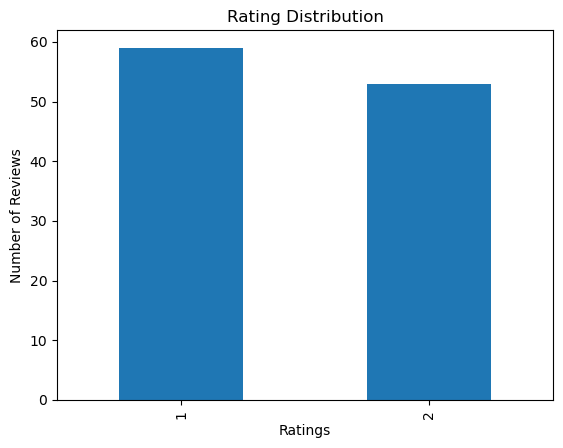

In [22]:
df['reviews.rating'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Ratings")
plt.ylabel("Number of Reviews")
plt.title("Rating Distribution")
plt.show()

In [23]:
negative_reviews['brand'].value_counts().head(10)

brand
Amazon    112
Name: count, dtype: int64

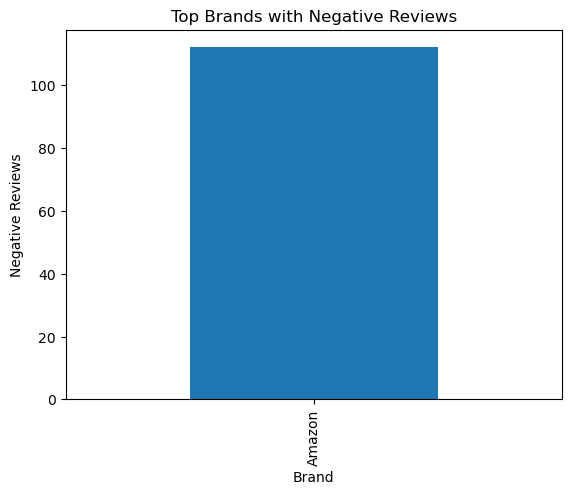

In [24]:
negative_reviews['brand'].value_counts().head(10).plot(kind='bar')
plt.xlabel("Brand")
plt.ylabel("Negative Reviews")
plt.title("Top Brands with Negative Reviews")
plt.show()

In [25]:
df.groupby('categories')['reviews.rating'].mean().sort_values().head(10)

categories
Tablets,Fire Tablets,Computers & Tablets,All Tablets                                                                                                                                                                                                                                      1.000000
eBook Readers,E-Readers & Accessories,Amazon Book Reader,Computers & Tablets,Amazon Ereaders,Kindle E-readers,E-Readers                                                                                                                                                                   1.000000
Fire Tablets,Tablets,Computers/Tablets & Networking,Other Computers & Networking,Computers & Tablets,All Tablets                                                                                                                                                                          1.000000
Kindle E-readers,Electronics Features,Computers & Tablets,E-Readers & Accessories,E-Readers,eBook Readers           

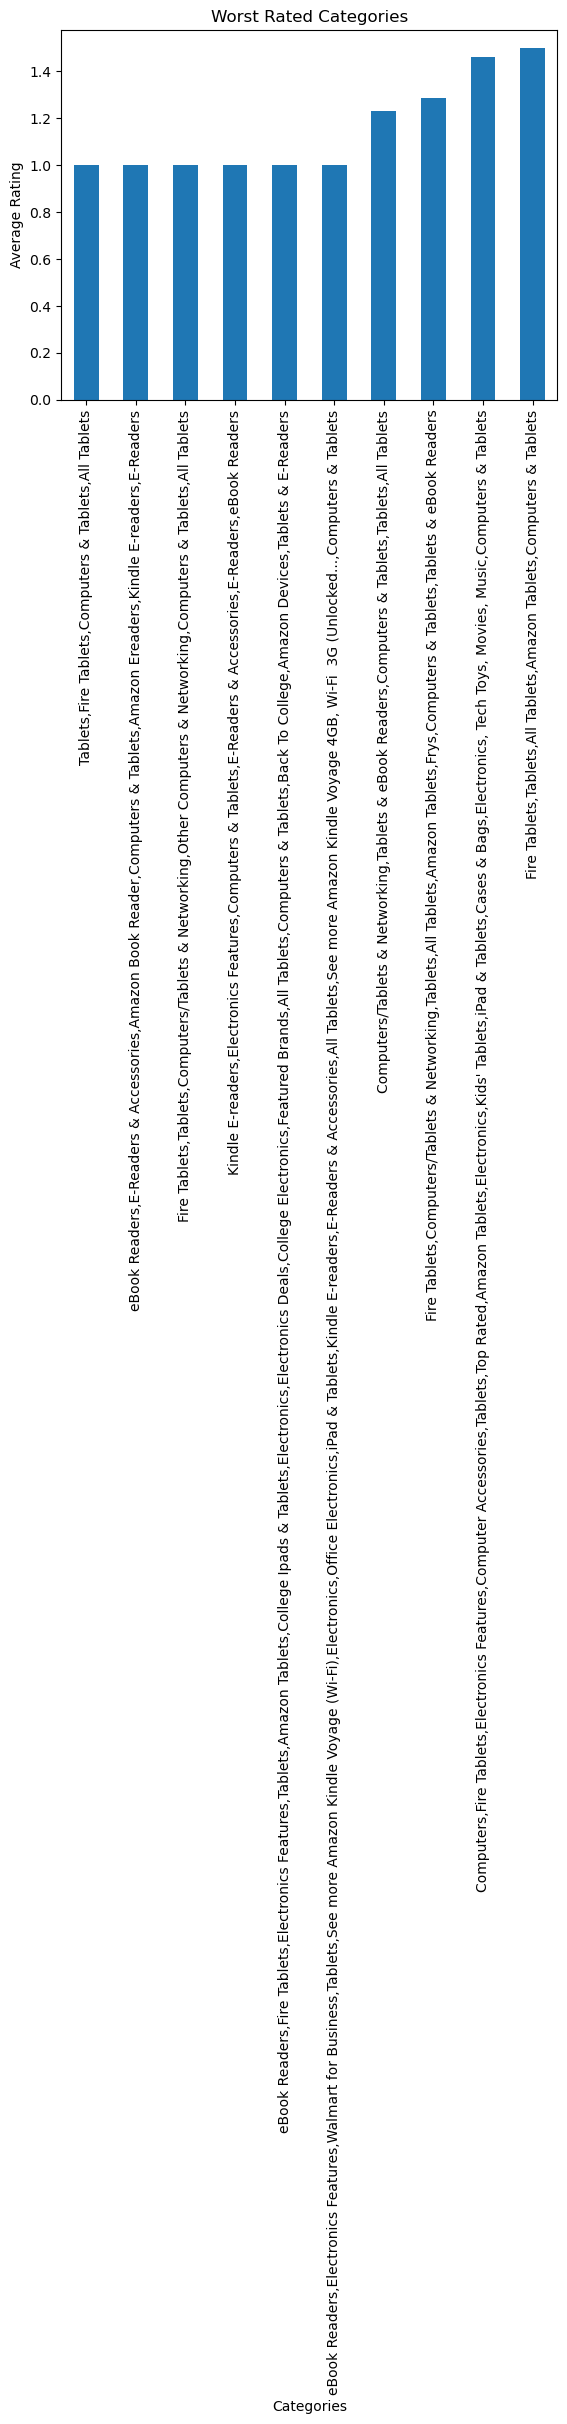

In [26]:
df.groupby('categories')['reviews.rating'].mean().sort_values().head(10).plot(kind='bar')
plt.xlabel("Categories")
plt.ylabel("Average Rating")
plt.title("Worst Rated Categories")
plt.show()

In [27]:
df.to_csv(r"C:\Users\ADMIN\Downloads\Amazon Review Analysis Dataset\Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv", index=False)

In [28]:
df['brand'].value_counts()

brand
Amazon    112
Name: count, dtype: int64

In [29]:
df['categories'].nunique() 

18

In [30]:
negative_reviews = df[df['reviews.rating']<=2]

In [31]:
negative_reviews.head()

,name,brand,categories,reviews.rating,reviews.text
0,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,"Computers,Electronics Features,Tablets,Electro...",1,I was looking for a kindle whitepaper. I saw o...
1,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,"Computers,Electronics Features,Tablets,Electro...",1,Looking at the picture and seeing it was 8th g...
2,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,"Computers,Electronics Features,Tablets,Electro...",2,it would not load my books proper. took a doze...
3,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,"Computers,Electronics Features,Tablets,Electro...",2,"The screen is too dark, and cannot adjust the ..."
4,Amazon Echo Show Alexa-enabled Bluetooth Speak...,Amazon,"Computers,Amazon Echo,Virtual Assistant Speake...",2,I have to say it was a little confusing and fr...


In [32]:
negative_reviews.to_csv(r"C:\Users\ADMIN\Downloads\Amazon Review Analysis Dataset\negative_review.csv", index=False)

In [33]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [34]:
from nltk.corpus import stopwords
from collections import Counter
import re

#get english stop words
stop_words = set(stopwords.words('english'))

#Combine all negative reviews
all_negative_text = "".join(negative_reviews['reviews.text'])

#Convert all negative reviews
all_negative_text = all_negative_text.lower()

#remove punctuation
all_negative_text = re.sub(r'[^\w\s]','', all_negative_text)

#Spit into words
words =  all_negative_text.split()

#Remove stop words and short words
filtered_words = [
    word for word in words
    if word not in stop_words and len(word) > 2
]

#count frequencies
word_counts = Counter(filtered_words)

#show top 20 words
word_counts.most_common(20)

[('amazon', 37),
 ('use', 28),
 ('tablet', 26),
 ('bought', 25),
 ('one', 24),
 ('work', 24),
 ('kindle', 23),
 ('apps', 23),
 ('would', 21),
 ('buy', 20),
 ('device', 18),
 ('get', 16),
 ('product', 14),
 ('could', 14),
 ('week', 14),
 ('year', 13),
 ('time', 12),
 ('screen', 12),
 ('old', 12),
 ('dont', 12)]

In [34]:
from nltk.corpus import stopwords
from collections import Counter
import re

# Standard English stop words
stop_words = set(stopwords.words('english'))

# Custom stop words specific to this dataset
custom_stop_words = {
    'amazon', 'one', 'would', 'could', 'get', 'got',
    'buy', 'bought', 'use', 'used', 'using',
    'product', 'device', 'time', 'year', 'years',
    'week', 'old', 'new', 'also', 'even', 'still',
    'dont', 'didnt', 'cant', 'ive', 'im',
    'kindle', 'tablet', 'work', 'great', 'good',
    'best', 'like', 'first', 'customer'
}

stop_words.update(custom_stop_words)

# Combine all negative reviews
all_negative_text = " ".join(negative_reviews['reviews.text'])

# Convert to lowercase
all_negative_text = all_negative_text.lower()

# Remove punctuation
all_negative_text = re.sub(r"[^\w\s]", " ", all_negative_text)

# Split into words
words = all_negative_text.split()

# Remove stop words and short words
filtered_words = [
    word for word in words
    if word not in stop_words and len(word) > 2
]

# Count word frequencies
word_counts = Counter(filtered_words)

# Display top 30 words
word_counts.most_common(30)

[('apps', 24),
 ('last', 13),
 ('screen', 12),
 ('junk', 12),
 ('back', 11),
 ('purchased', 11),
 ('echo', 11),
 ('show', 11),
 ('returned', 11),
 ('charge', 11),
 ('fire', 11),
 ('quality', 11),
 ('useless', 10),
 ('phone', 9),
 ('better', 9),
 ('video', 9),
 ('friendly', 9),
 ('problem', 9),
 ('know', 9),
 ('slow', 9),
 ('generation', 8),
 ('make', 8),
 ('nothing', 8),
 ('less', 8),
 ('days', 8),
 ('ipad', 8),
 ('speakers', 8),
 ('constantly', 8),
 ('going', 8),
 ('much', 8)]

In [35]:
import pandas as pd

#Covert counter to dataframe
word_df = pd.DataFrame(
    word_counts.most_common(50),
    columns=["Word", "Frequency"]
)

word_df.head()

,Word,Frequency
0,apps,24
1,last,13
2,screen,12
3,junk,12
4,back,11


In [37]:
word_df.to_csv(
    r"C:\Users\ADMIN\Downloads\Amazon Review Analysis Dataset\complaint_keywords.csv",
    index=False
)